# Feedback control

In [4]:
import numpy as np
import scipy.sparse as sp
import matplotlib.pyplot as plt
from numpy.linalg import norm

Total power (energy/time) =  0.0035117228498178716
Trajectory distance (control vs undisturbed): 0.025621830296897824
Trajectory distance (no control vs undisturbed): 0.14740091998227556


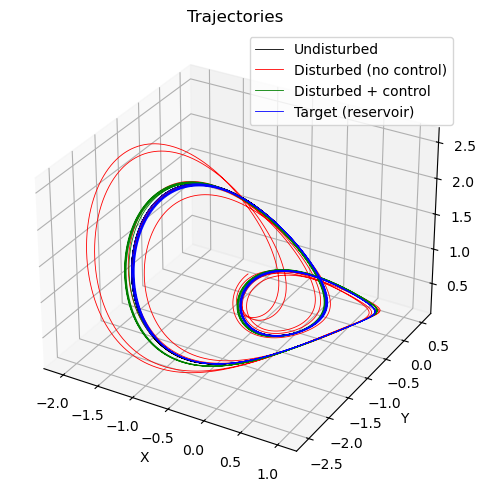

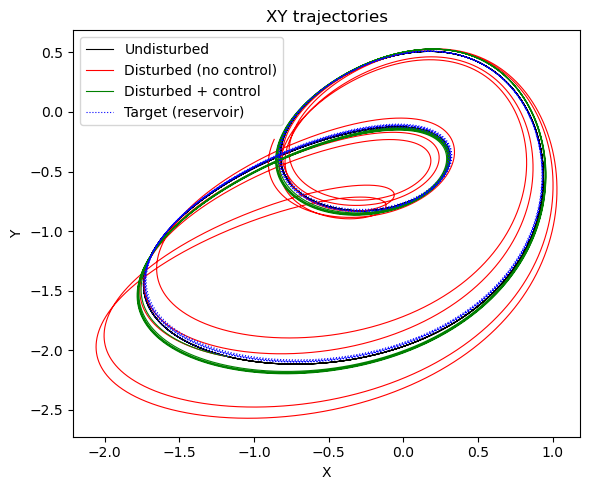

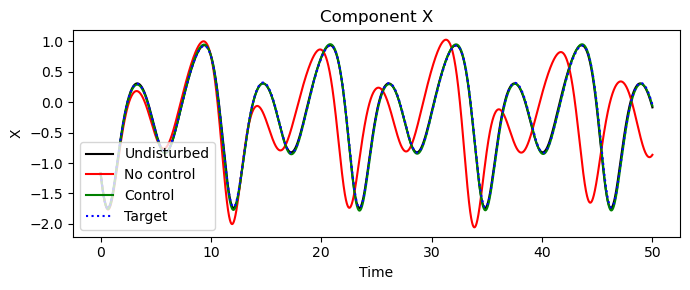

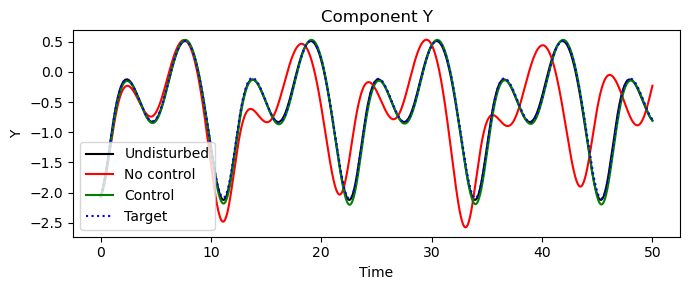

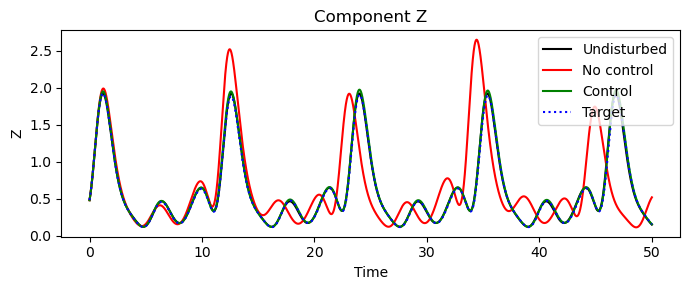

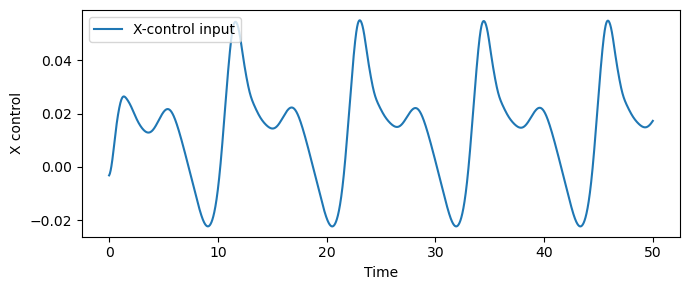

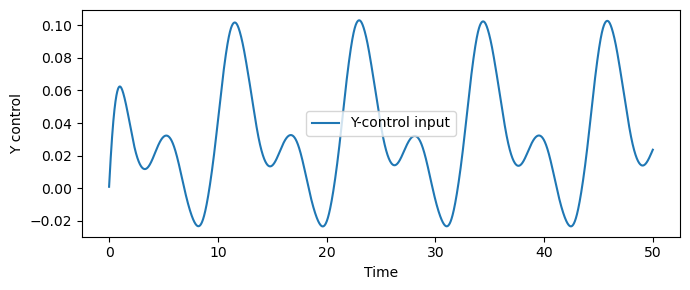

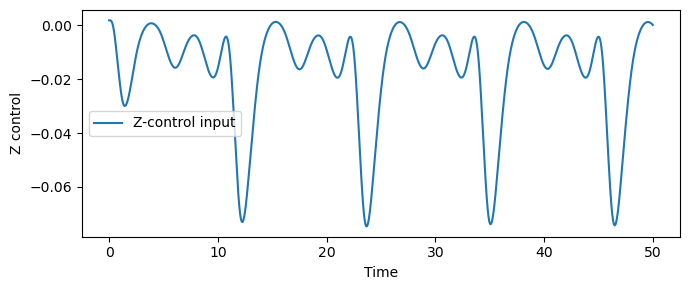

In [1]:
from dataclasses import dataclass
from typing import Callable, Dict, Tuple, Optional
import numpy as np
import scipy.sparse as sp
import matplotlib.pyplot as plt


# 1) Dynamical systems
def sprott_linz_deriv(x: np.ndarray, params: Dict[str, float]) -> np.ndarray:
    a = params.get('a', 0.42)
    x_, y_, z_ = x
    return np.array([y_ + z_, -x_ + a * y_, x_**2 - z_])


def lorenz_deriv(x: np.ndarray, params: Dict[str, float]) -> np.ndarray:
    sigma = params.get('sigma', 10.0)
    rho   = params.get('rho', 28.0)
    beta  = params.get('beta', 8.0/3.0)
    x_, y_, z_ = x
    return np.array([sigma * (y_ - x_), x_ * (rho - z_) - y_, x_ * y_ - beta * z_])


def get_system(system_name: str) -> Tuple[Callable[[np.ndarray, Dict[str,float]], np.ndarray], Dict[str, float]]:
    name = system_name.lower()
    if name in ['sprott-linz', 'sprott_linz', 'sprott']:
        return sprott_linz_deriv, {'a': 0.42}
    if name in ['lorenz', 'lorenz63']:
        return lorenz_deriv, {'sigma': 10.0, 'rho': 28.0, 'beta': 8.0/3.0}
    raise ValueError(f"Unknown system '{system_name}'. Use 'sprott-linz' or 'lorenz'.")

# 2) Integrators
def euler_step(f: Callable[[np.ndarray, Dict[str,float]], np.ndarray], x: np.ndarray, dt: float, params: Dict[str,float]) -> np.ndarray:
    return x + dt * f(x, params)


def rk4_step(f: Callable[[np.ndarray, Dict[str,float]], np.ndarray], x: np.ndarray, dt: float, params: Dict[str,float]) -> np.ndarray:
    k1 = f(x, params)
    k2 = f(x + 0.5 * dt * k1, params)
    k3 = f(x + 0.5 * dt * k2, params)
    k4 = f(x + dt * k3, params)
    return x + (dt/6.0)*(k1 + 2*k2 + 2*k3 + k4)


def get_stepper(method: str):
    method = method.lower()
    if method == 'euler':
        return euler_step
    if method in ['rk4', 'runge-kutta', 'rk']:
        return rk4_step
    raise ValueError("Integrator must be 'euler' or 'rk4'.")
    
# 3) Reservoir and training (aligned with forecast.ipynb)
@dataclass
class Reservoir:
    A: sp.csr_matrix
    Win: np.ndarray
    bias: float


def build_reservoir(n: int, m: int, spectral_radius: float = 1.2, density: float = 6.0, input_scale: float = 0.1,
                     bias: float = 1.0, seed: Optional[int] = None) -> Reservoir:
    rng = np.random.default_rng(seed)
    A_rand = sp.random(n, n, density=density/n, format='csr', random_state=seed)
    A_data = A_rand.toarray()
    A_data = A_data - 0.5 * np.sign(A_data)
    A_temp = sp.csr_matrix(A_data)
    eigvals = sp.linalg.eigs(A_temp, k=1, which='LR', return_eigenvectors=False)
    A_scaled = A_temp * (spectral_radius / np.abs(eigvals[0]))
    Win = input_scale*(2.0 * rng.random((n, m)) - 1.0)
    return Reservoir(A=A_scaled.tocsr(), Win=Win, bias=bias)


def train_reservoir(deriv: Callable, params: Dict[str,float], reservoir: Reservoir, x0: np.ndarray,
                    T: float, dt: float, lam: float = 1e-4, washout: int = 1000,
                    integrator: str = 'rk4', seed: Optional[int] = None) -> Dict[str, np.ndarray]:
    stepper = get_stepper(integrator)
    n_steps = int(T / dt)
    m = len(x0)
    n = reservoir.A.shape[0]
    rng = np.random.default_rng(seed)
    R = np.zeros((n, n_steps))
    F = np.zeros((m, n_steps))
    r = 2.0 * rng.random(n) - 1.0
    x = x0.copy()
    for t in range(n_steps):
        u = x.copy()
        R[:, t] = r
        F[:, t] = u
        x = stepper(deriv, x, dt, params)
        r = np.tanh(reservoir.A.dot(r) + reservoir.Win.dot(u) + reservoir.bias)
    if washout >= n_steps:
        raise ValueError("Washout >= total steps; reduce washout or increase T.")
    R_eff = R[:, washout:]
    F_eff = F[:, washout:]
    Id = np.eye(n)
    Wout = F_eff.dot(R_eff.T).dot(np.linalg.inv(R_eff.dot(R_eff.T) + lam * Id))
    return {'Wout': Wout, 'x_last': x, 'r_last': r}

# 4) Feedback control simulation
from typing import List

def apply_value_disturbance(params: Dict[str,float], disturb_value: float, key: str) -> Dict[str,float]:
    newp = dict(params)
    newp[key] = params[key] + disturb_value
    return newp

def trajectory_shortest_distance(true: np.ndarray, pred: np.ndarray, n_samples: int = 100, seed: Optional[int] = None) -> float:
    T_pred = pred.shape[1]
    if T_pred == 0:
        return float('nan')
    n_eff = min(n_samples, T_pred)
    rng = np.random.default_rng(seed)
    idxs = rng.choice(T_pred, size=n_eff, replace=False)
    total = 0.0
    for idx in idxs:
        p = pred[:, idx][:, None]
        dists = np.linalg.norm(true - p, axis=0)
        total += float(dists.min())
    return total / n_eff
    
def simulate_feedback(
    system_name: str = 'sprott-linz',
    system_params: Optional[Dict[str,float]] = None,
    disturb_key: Optional[str] = None,
    disturb_value: float = 0.0,
    training_time: float = 300.0,
    forecast_time: float = 50.0,
    dt: float = 0.002,
    reservoir_size: int = 500,
    spectral_radius: float = 1.2,
    density: float = 6.0,
    input_scale: float = 0.1,
    bias: float = 1.0,
    lam: float = 1e-4,
    washout: int = 1000,
    integrator: str = 'rk4',
    seed: int = 42,
    control_gain: float = 1.0,
) -> Dict[str, np.ndarray]:
    deriv, default_params = get_system(system_name)
    if system_params:
        default_params.update(system_params)
    params_nominal = default_params

    if disturb_key is None:
        disturb_key = next(iter(params_nominal.keys()))
    params_disturbed = apply_value_disturbance(params_nominal, disturb_value, disturb_key)

    rng = np.random.default_rng(seed)
    x0 = rng.random(3) - 0.5
    reservoir = build_reservoir(n=reservoir_size, m=3, spectral_radius=spectral_radius, density=density,
                                input_scale=input_scale, bias=bias, seed=seed)
    tr = train_reservoir(deriv, params_nominal, reservoir, x0, T=training_time, dt=dt, lam=lam,
                         washout=washout, integrator=integrator, seed=seed)

    n_steps = int(forecast_time / dt)
    times = np.linspace(0.0, forecast_time, n_steps)

    undist = np.zeros((3, n_steps))
    noctrl = np.zeros((3, n_steps))
    ctrl   = np.zeros((3, n_steps))
    targets = np.zeros((3, n_steps))
    control_inputs = np.zeros((3, n_steps))

    x_u = tr['x_last'].copy()
    x_n = tr['x_last'].copy()
    x_c = tr['x_last'].copy()
    r = tr['r_last'].copy()
    
    x_target = tr['x_last'].copy()

    stepper = get_stepper(integrator)

    f_nominal   = lambda xx, pp: deriv(xx, params_nominal)
    f_disturbed = lambda xx, pp: deriv(xx, params_disturbed)

    for t in range(n_steps):
        undist[:, t] = x_u
        noctrl[:, t] = x_n
        ctrl[:, t]   = x_c

        x_u = stepper(f_nominal, x_u, dt, None)
        x_n = stepper(f_disturbed, x_n, dt, None)

        # 1. Update reservoir state using its *own previous prediction* (x_target) as input.
        r = np.tanh(reservoir.A.dot(r) + reservoir.Win.dot(x_target) + reservoir.bias)
        
        # 2. Generate the new target state (the next step of the autonomous forecast).
        current_target = tr['Wout'].dot(r)
        
        # 3. CRITICAL: Update the target state for the *next* iteration.
        x_target = current_target.copy()
        
        # 4. Calculate control input based on the difference between the generated target and the actual system state.
        u = control_gain * (current_target - x_c)

        # Store control info
        targets[:, t] = current_target
        control_inputs[:, t] = u

        x_c = stepper(lambda xx, pp: f_disturbed(xx, None) + u, x_c, dt, None)

    return {
        'times': times,
        'undisturbed': undist,
        'disturbed_no_control': noctrl,
        'disturbed_control': ctrl,
        'targets': targets,
        'control_inputs': control_inputs,
        'params_nominal': params_nominal,
        'params_disturbed': params_disturbed,
        'disturbance_key': np.array([disturb_key], dtype=object),
        'disturbance_value': np.array([disturb_value]),
    }


# 5) Evaluation utilities

def evaluate_control(results: Dict[str, np.ndarray], dt: float, n_samples: int = 200, seed: Optional[int] = None) -> Dict[str, float]:
    und = results['undisturbed']
    noc = results['disturbed_no_control']
    ctr = results['disturbed_control']

    # Distances
    dist_ctrl = trajectory_shortest_distance(und, ctr, n_samples=n_samples, seed=seed)
    dist_noc = trajectory_shortest_distance(und, noc, n_samples=n_samples, seed=seed)

    # Total power (energy/time) using control inputs directly
    times = results['times']
    Ttest = float(times[-1] - times[0]) if times.size > 0 else 0.0
    u = results.get('control_inputs')
    if u is None or Ttest <= 0.0:
        total_power = float('nan')
    else:
        # u has shape (3, T); compute time-average of squared control magnitude
        total_power = np.sum(dt * np.sum(u**2, axis=0)) / Ttest

    print("Total power (energy/time) = ", total_power)
    return {
        'control_distance': float(dist_ctrl),
        'no_control_distance': float(dist_noc),
        'total_power': float(total_power)
    }

# 6) Plotting utilities
from typing import Tuple

def plot_feedback_results(results: Dict[str, np.ndarray], from_time: float = 0.0, to_time: Optional[float] = None):
    times = results['times']
    und  = results['undisturbed']
    noc  = results['disturbed_no_control']
    ctr  = results['disturbed_control']
    tgt  = results['targets']

    if to_time is None:
        to_time = float(times[-1])
    mask = (times >= from_time) & (times <= to_time)
    t = times[mask]
    und_sel, noc_sel, ctr_sel, tgt_sel = und[:, mask], noc[:, mask], ctr[:, mask], tgt[:, mask]

    # 3D trajectories
    fig = plt.figure(figsize=(6, 5))
    ax = fig.add_subplot(111, projection='3d')
    ax.plot(und_sel[0], und_sel[1], und_sel[2], 'k', lw=0.6, label='Undisturbed')
    ax.plot(noc_sel[0], noc_sel[1], noc_sel[2], 'r', lw=0.6, label='Disturbed (no control)')
    ax.plot(ctr_sel[0], ctr_sel[1], ctr_sel[2], 'g', lw=0.6, label='Disturbed + control')
    ax.plot(tgt_sel[0], tgt_sel[1], tgt_sel[2], 'b', lw=0.6, label='Target (reservoir)')
    ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')
    ax.set_title('Trajectories')
    ax.legend(); plt.tight_layout()

    # 2D projections
    # Plot 2D projections of the 3D trajectories
    plt.figure(figsize=(6, 5))
    if und is not None:
        plt.plot(und[0, mask], und[1, mask], 'k', lw=0.8, label='Undisturbed')
    if noc is not None:
        plt.plot(noc[0, mask], noc[1, mask], 'r', lw=0.8, label='Disturbed (no control)')
    if ctr is not None:
        plt.plot(ctr[0, mask], ctr[1, mask], 'g', lw=0.8, label='Disturbed + control')
    if tgt is not None:
        plt.plot(tgt[0, mask], tgt[1, mask], color='b', lw=0.8, linestyle=':', label='Target (reservoir)')

    plt.xlabel('X')
    plt.ylabel('Y')
    plt.title('XY trajectories')
    plt.legend()
    plt.tight_layout()    

    comps = ['X','Y','Z']
    for i in range(3):
        plt.figure(figsize=(7, 3))
        plt.plot(t, und_sel[i], 'k', label='Undisturbed')
        plt.plot(t, noc_sel[i], 'r', label='No control')
        plt.plot(t, ctr_sel[i], 'g', label='Control')
        plt.plot(t, tgt_sel[i], color='b', linestyle=':', label='Target')
        plt.xlabel('Time'); plt.ylabel(comps[i])
        plt.title(f'Component {comps[i]}')
        plt.legend(); plt.tight_layout()


def plot_control_inputs(times: np.ndarray, control_inputs: np.ndarray, from_time: float = 0.0, to_time: Optional[float] = None):
    if to_time is None:
        to_time = float(times[-1])
    mask = (times >= from_time) & (times <= to_time)
    t = times[mask]
    u = control_inputs[:, mask]
    comps = ['X','Y','Z']
    for i in range(3):
        plt.figure(figsize=(7, 3))
        plt.plot(t, u[i], label=f'{comps[i]}-control input')
        plt.xlabel('Time'); plt.ylabel(f'{comps[i]} control')
        plt.legend(); plt.tight_layout()

# 7) Parameters and demo run
system_name = 'sprott-linz'   # 'sprott-linz' or 'lorenz'
system_params = {'a': 0.34}
#system_params = {'rho': 28, 'sigma': 10.0, 'beta': 8.0/3.0}         # e.g., {'a': 0.42} or {'rho': 30.0}


training_time = 300.0
forecast_time = 50.0
dt = 0.002

reservoir_size = 1000
spectral_radius = 1.2
density = 6.0
input_scale = 0.1
bias = 1.0
lam = 1e-4
washout = 0
integrator = 'euler'
seed = 121
control_gain = 1.0

# Disturbance configuration (absolute delta on a chosen parameter key)
disturb_key = 'a'       # if None, will pick first parameter key by default
disturb_value = 0.0622    # e.g., add +0.05 to that parameter

res = simulate_feedback(
    system_name=system_name,
    system_params=system_params,
    disturb_key=disturb_key,
    disturb_value=disturb_value,
    training_time=training_time,
    forecast_time=forecast_time,
    dt=dt,
    reservoir_size=reservoir_size,
    spectral_radius=spectral_radius,
    density=density,
    input_scale=input_scale,
    bias=bias,
    lam=lam,
    washout=washout,
    integrator=integrator,
    seed=seed,
    control_gain=control_gain,
)

metrics = evaluate_control(res, dt=dt, n_samples=200, seed=seed)
print('Trajectory distance (control vs undisturbed):', metrics['control_distance'])
print('Trajectory distance (no control vs undisturbed):', metrics['no_control_distance'])
plot_feedback_results(res, from_time=0.0, to_time=min(60.0, float(res['times'][-1])))

# 8) Plot control inputs
plot_control_inputs(res['times'], res['control_inputs'], from_time=0.0, to_time=min(60.0, float(res['times'][-1])))

## Parameter sweep: disturbance magnitude (disturb_value)
We sweep disturb_value from 0.00 to 0.10 in steps of 0.01, run the feedback simulation for each, and record trajectory distances and control power.

In [30]:
# Sweep disturb_value from 0.00 to 0.10 (step 0.01), run once per value, and log metrics
import numpy as np
from time import time

# Ensure functions from earlier cells are available: simulate_feedback, evaluate_control

# Base config (reuse values from the earlier demo cell if defined)
try:
    system_name
except NameError:
    system_name = 'sprott-linz'
try:
    system_params
except NameError:
    system_params = {'a': 0.34}
try:
    training_time
except NameError:
    training_time = 300.0
try:
    forecast_time
except NameError:
    forecast_time = 50.0
try:
    dt
except NameError:
    dt = 0.002
try:
    reservoir_size
except NameError:
    reservoir_size = 1000
try:
    spectral_radius
except NameError:
    spectral_radius = 1.2
try:
    density
except NameError:
    density = 6.0
try:
    input_scale
except NameError:
    input_scale = 0.1
try:
    bias
except NameError:
    bias = 1.0
try:
    lam
except NameError:
    lam = 1e-4
try:
    washout
except NameError:
    washout = 0
try:
    integrator
except NameError:
    integrator = 'euler'
try:
    seed
except NameError:
    seed = 100
try:
    control_gain
except NameError:
    control_gain = 1.0

# Disturbance key: preserve previous choice or default to first system param
try:
    disturb_key
except NameError:
    disturb_key = None

# Sweep values
values = np.round(np.arange(-0.10, 0.10 + 1e-12, 0.01), 2)

sweep_metrics = []
start_all = time()
print(f"Starting disturb_value sweep over {len(values)} values...")

for i, dv in enumerate(values, start=1):
    t0 = time()
    res = simulate_feedback(
        system_name=system_name,
        system_params=system_params,
        disturb_key=disturb_key,
        disturb_value=float(dv),
        training_time=training_time,
        forecast_time=forecast_time,
        dt=dt,
        reservoir_size=reservoir_size,
        spectral_radius=spectral_radius,
        density=density,
        input_scale=input_scale,
        bias=bias,
        lam=lam,
        washout=washout,
        integrator=integrator,
        seed=seed + i,   # vary seed slightly per run
        control_gain=control_gain,
    )
    mets = evaluate_control(res, dt=dt, n_samples=200, seed=seed + i)
    sweep_metrics.append({
        'disturb_value': float(dv),
        'control_distance': float(mets['control_distance']),
        'no_control_distance': float(mets['no_control_distance']),
        'total_power': float(mets['total_power']),
    })
    print(f"[{i}/{len(values)}] dv={dv:.2f} -> ctrl_dist={mets['control_distance']:.6f}, noc_dist={mets['no_control_distance']:.6f}, power={mets['total_power']:.6f}  (elapsed {time()-t0:.1f}s)")

print(f"Sweep complete in {(time()-start_all)/60.0:.1f} min.")

# Bundle for plotting/analysis
sweep_disturbance = {
    'disturb_values': np.array([m['disturb_value'] for m in sweep_metrics], dtype=float),
    'control_distance': np.array([m['control_distance'] for m in sweep_metrics], dtype=float),
    'no_control_distance': np.array([m['no_control_distance'] for m in sweep_metrics], dtype=float),
    'total_power': np.array([m['total_power'] for m in sweep_metrics], dtype=float),
    'raw': sweep_metrics,
}
sweep_disturbance

Starting disturb_value sweep over 21 values...
Total power (energy/time) =  0.007712439076598365
[1/21] dv=-0.10 -> ctrl_dist=0.064820, noc_dist=0.387093, power=0.007712  (elapsed 9.7s)
Total power (energy/time) =  0.0066514624168212775
[2/21] dv=-0.09 -> ctrl_dist=0.044299, noc_dist=0.329672, power=0.006651  (elapsed 6.2s)
Total power (energy/time) =  0.005123054312385043
[3/21] dv=-0.08 -> ctrl_dist=0.060442, noc_dist=0.324393, power=0.005123  (elapsed 5.5s)
Total power (energy/time) =  0.003763025230603556
[4/21] dv=-0.07 -> ctrl_dist=0.046574, noc_dist=0.359602, power=0.003763  (elapsed 5.5s)


/var/folders/08/2nzzvlmn2n15r4kk5102nk6m0000gn/T/ipykernel_42824/753968342.py:12: RuntimeWarning: overflow encountered in scalar power
  return np.array([y_ + z_, -x_ + a * y_, x_**2 - z_])
/var/folders/08/2nzzvlmn2n15r4kk5102nk6m0000gn/T/ipykernel_42824/753968342.py:12: RuntimeWarning: invalid value encountered in scalar subtract
  return np.array([y_ + z_, -x_ + a * y_, x_**2 - z_])


Total power (energy/time) =  nan
[5/21] dv=-0.06 -> ctrl_dist=nan, noc_dist=nan, power=nan  (elapsed 6.6s)
Total power (energy/time) =  0.0019368599371216118
[6/21] dv=-0.05 -> ctrl_dist=0.033067, noc_dist=0.247607, power=0.001937  (elapsed 7.7s)
Total power (energy/time) =  0.0011423293391207869
[7/21] dv=-0.04 -> ctrl_dist=0.015631, noc_dist=0.143345, power=0.001142  (elapsed 6.2s)
Total power (energy/time) =  0.0007397670894186341
[8/21] dv=-0.03 -> ctrl_dist=0.018517, noc_dist=0.106000, power=0.000740  (elapsed 6.8s)
Total power (energy/time) =  0.00022069423672671975
[9/21] dv=-0.02 -> ctrl_dist=0.007140, noc_dist=0.061435, power=0.000221  (elapsed 5.3s)
Total power (energy/time) =  0.00018448884383507602
[10/21] dv=-0.01 -> ctrl_dist=0.024321, noc_dist=0.030009, power=0.000184  (elapsed 5.5s)
Total power (energy/time) =  2.3228428382949043e-05
[11/21] dv=-0.00 -> ctrl_dist=0.011392, noc_dist=0.000000, power=0.000023  (elapsed 5.2s)
Total power (energy/time) =  5.3695145551141845e

{'disturb_values': array([-0.1 , -0.09, -0.08, -0.07, -0.06, -0.05, -0.04, -0.03, -0.02,
        -0.01, -0.  ,  0.01,  0.02,  0.03,  0.04,  0.05,  0.06,  0.07,
         0.08,  0.09,  0.1 ]),
 'control_distance': array([0.0648202 , 0.04429921, 0.060442  , 0.04657389,        nan,
        0.03306675, 0.01563066, 0.01851712, 0.00714036, 0.02432068,
        0.01139193, 0.01250704, 0.01512323, 0.02319054, 0.02313859,
        0.03710351, 0.047699  , 0.03798735, 0.06392206, 0.05392501,
        0.04568687]),
 'no_control_distance': array([0.38709332, 0.32967222, 0.32439284, 0.35960239,        nan,
        0.24760655, 0.14334495, 0.10599991, 0.06143519, 0.03000898,
        0.        , 0.03120247, 0.05697416, 0.09329969, 0.10028214,
        0.16109302, 0.23893786, 0.20121697, 0.29453145, 0.37139477,
        0.49422498]),
 'total_power': array([7.71243908e-03, 6.65146242e-03, 5.12305431e-03, 3.76302523e-03,
                   nan, 1.93685994e-03, 1.14232934e-03, 7.39767089e-04,
        2.20694237e

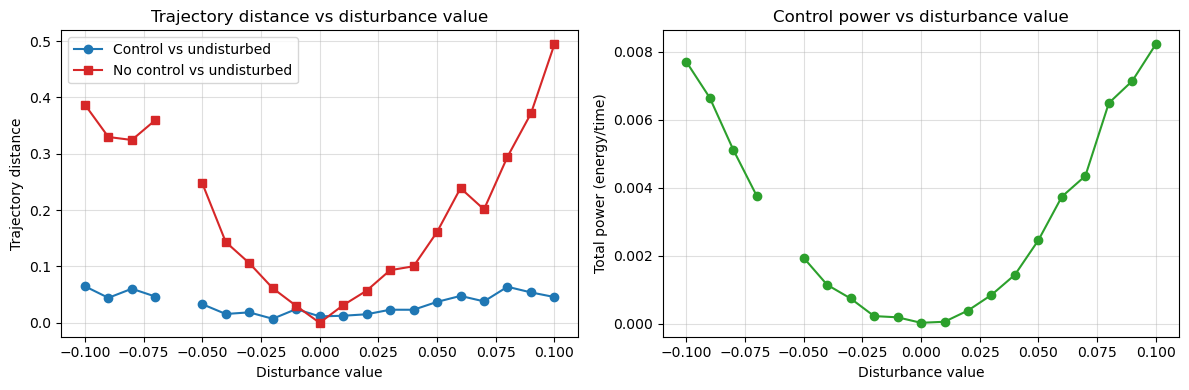

In [31]:
# Plot metrics vs disturb_value (overlay control and no-control distances)
import matplotlib.pyplot as plt
import numpy as np

vals = np.array(sweep_disturbance['disturb_values'], dtype=float)
cd = np.array(sweep_disturbance['control_distance'], dtype=float)
nc = np.array(sweep_disturbance['no_control_distance'], dtype=float)
pw = np.array(sweep_disturbance['total_power'], dtype=float)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Overlay distances on same plot
axes[0].plot(vals, cd, marker='o', label='Control vs undisturbed')
axes[0].plot(vals, nc, marker='s', color='tab:red', label='No control vs undisturbed')
axes[0].set_xlabel('Disturbance value')
axes[0].set_ylabel('Trajectory distance')
axes[0].set_title('Trajectory distance vs disturbance value')
axes[0].grid(True, alpha=0.4)
axes[0].legend()

# Power subplot
axes[1].plot(vals, pw, marker='o', color='tab:green')
axes[1].set_xlabel('Disturbance value')
axes[1].set_ylabel('Total power (energy/time)')
axes[1].set_title('Control power vs disturbance value')
axes[1].grid(True, alpha=0.4)

plt.tight_layout()
plt.show()

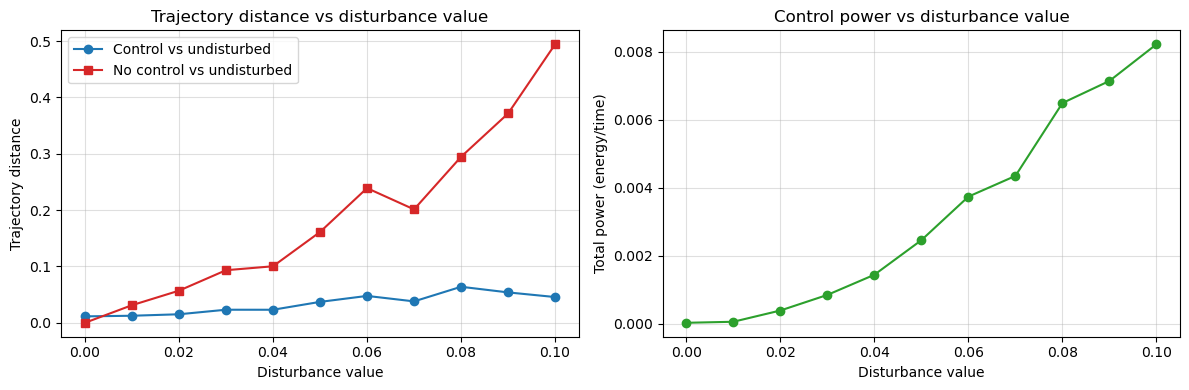

In [32]:
# Plot only the final half of the disturb_values

vals = vals[len(vals)//2:]
cd = cd[len(cd)//2:]
nc = nc[len(nc)//2:]
pw = pw[len(pw)//2:]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Overlay distances on same plot
axes[0].plot(vals, cd, marker='o', label='Control vs undisturbed')
axes[0].plot(vals, nc, marker='s', color='tab:red', label='No control vs undisturbed')
axes[0].set_xlabel('Disturbance value')
axes[0].set_ylabel('Trajectory distance')
axes[0].set_title('Trajectory distance vs disturbance value')
axes[0].grid(True, alpha=0.4)
axes[0].legend()

# Power subplot
axes[1].plot(vals, pw, marker='o', color='tab:green')
axes[1].set_xlabel('Disturbance value')
axes[1].set_ylabel('Total power (energy/time)')
axes[1].set_title('Control power vs disturbance value')
axes[1].grid(True, alpha=0.4)

plt.tight_layout()
plt.show()


## Parameter sweep: disturbance magnitude (disturb_value)
We sweep disturb_value from -10 to 10 in steps of 1 for lorenz system, run the feedback simulation for each, and record trajectory distances and control power.

In [28]:
# Sweep disturb_value from 0.00 to 0.10 (step 0.01), run once per value, and log metrics
import numpy as np
from time import time

# Ensure functions from earlier cells are available: simulate_feedback, evaluate_control

# Base config (reuse values from the earlier demo cell if defined)
try:
    system_name
except NameError:
    system_name = 'lorenz'
try:
    system_params
except NameError:
    system_params = {'rho': 28.0, 'sigma': 10.0, 'beta': 8.0/3.0}
try:
    training_time
except NameError:
    training_time = 300.0
try:
    forecast_time
except NameError:
    forecast_time = 50.0
try:
    dt
except NameError:
    dt = 0.002
try:
    reservoir_size
except NameError:
    reservoir_size = 1000
try:
    spectral_radius
except NameError:
    spectral_radius = 1.2
try:
    density
except NameError:
    density = 6.0
try:
    input_scale
except NameError:
    input_scale = 0.1
try:
    bias
except NameError:
    bias = 1.0
try:
    lam
except NameError:
    lam = 1e-5
try:
    washout
except NameError:
    washout = 0
try:
    integrator
except NameError:
    integrator = 'euler'
try:
    seed
except NameError:
    seed = 100
try:
    control_gain
except NameError:
    control_gain = 1.0

# Disturbance key: preserve previous choice or default to first system param
try:
    disturb_key
except NameError:
    disturb_key = None

# Sweep values
values = np.round(np.arange(-10.0, 10.0 + 1e-12, 1), 2)

sweep_metrics = []
start_all = time()
print(f"Starting disturb_value sweep over {len(values)} values...")

for i, dv in enumerate(values, start=1):
    t0 = time()
    res = simulate_feedback(
        system_name=system_name,
        system_params=system_params,
        disturb_key=disturb_key,
        disturb_value=float(dv),
        training_time=training_time,
        forecast_time=forecast_time,
        dt=dt,
        reservoir_size=reservoir_size,
        spectral_radius=spectral_radius,
        density=density,
        input_scale=input_scale,
        bias=bias,
        lam=lam,
        washout=washout,
        integrator=integrator,
        seed=seed + i,   # vary seed slightly per run
        control_gain=control_gain,
    )
    mets = evaluate_control(res, dt=dt, n_samples=3000, seed=seed + i)
    sweep_metrics.append({
        'disturb_value': float(dv),
        'control_distance': float(mets['control_distance']),
        'no_control_distance': float(mets['no_control_distance']),
        'total_power': float(mets['total_power']),
    })
    print(f"[{i}/{len(values)}] dv={dv:.2f} -> ctrl_dist={mets['control_distance']:.6f}, noc_dist={mets['no_control_distance']:.6f}, power={mets['total_power']:.6f}  (elapsed {time()-t0:.1f}s)")

print(f"Sweep complete in {(time()-start_all)/60.0:.1f} min.")

# Bundle for plotting/analysis
sweep_disturbance = {
    'disturb_values': np.array([m['disturb_value'] for m in sweep_metrics], dtype=float),
    'control_distance': np.array([m['control_distance'] for m in sweep_metrics], dtype=float),
    'no_control_distance': np.array([m['no_control_distance'] for m in sweep_metrics], dtype=float),
    'total_power': np.array([m['total_power'] for m in sweep_metrics], dtype=float),
    'raw': sweep_metrics,
}
sweep_disturbance

Starting disturb_value sweep over 21 values...


/var/folders/08/2nzzvlmn2n15r4kk5102nk6m0000gn/T/ipykernel_42824/753968342.py:12: RuntimeWarning: overflow encountered in scalar power
  return np.array([y_ + z_, -x_ + a * y_, x_**2 - z_])
/var/folders/08/2nzzvlmn2n15r4kk5102nk6m0000gn/T/ipykernel_42824/753968342.py:12: RuntimeWarning: invalid value encountered in scalar subtract
  return np.array([y_ + z_, -x_ + a * y_, x_**2 - z_])


Total power (energy/time) =  1.1793333916712592
[1/21] dv=-10.00 -> ctrl_dist=0.288563, noc_dist=nan, power=1.179333  (elapsed 6.0s)
Total power (energy/time) =  1.2884721494740194
[2/21] dv=-9.00 -> ctrl_dist=0.291648, noc_dist=nan, power=1.288472  (elapsed 5.5s)
Total power (energy/time) =  1.2884721494740194
[2/21] dv=-9.00 -> ctrl_dist=0.291648, noc_dist=nan, power=1.288472  (elapsed 5.5s)
Total power (energy/time) =  1.0731355662515012
[3/21] dv=-8.00 -> ctrl_dist=0.286135, noc_dist=nan, power=1.073136  (elapsed 5.3s)
Total power (energy/time) =  1.0731355662515012
[3/21] dv=-8.00 -> ctrl_dist=0.286135, noc_dist=nan, power=1.073136  (elapsed 5.3s)
Total power (energy/time) =  0.9559136145935199
[4/21] dv=-7.00 -> ctrl_dist=0.291567, noc_dist=0.543810, power=0.955914  (elapsed 5.4s)
Total power (energy/time) =  0.9559136145935199
[4/21] dv=-7.00 -> ctrl_dist=0.291567, noc_dist=0.543810, power=0.955914  (elapsed 5.4s)
Total power (energy/time) =  nan
[5/21] dv=-6.00 -> ctrl_dist=nan

/var/folders/08/2nzzvlmn2n15r4kk5102nk6m0000gn/T/ipykernel_42824/753968342.py:236: RuntimeWarning: overflow encountered in square
  total_power = np.sum(dt * np.sum(u**2, axis=0)) / Ttest


Total power (energy/time) =  nan
[13/21] dv=2.00 -> ctrl_dist=nan, noc_dist=nan, power=nan  (elapsed 5.3s)
Total power (energy/time) =  nan
[14/21] dv=3.00 -> ctrl_dist=nan, noc_dist=nan, power=nan  (elapsed 5.3s)
Total power (energy/time) =  nan
[14/21] dv=3.00 -> ctrl_dist=nan, noc_dist=nan, power=nan  (elapsed 5.3s)
Total power (energy/time) =  nan
[15/21] dv=4.00 -> ctrl_dist=nan, noc_dist=nan, power=nan  (elapsed 5.2s)
Total power (energy/time) =  nan
[15/21] dv=4.00 -> ctrl_dist=nan, noc_dist=nan, power=nan  (elapsed 5.2s)
Total power (energy/time) =  nan
[16/21] dv=5.00 -> ctrl_dist=nan, noc_dist=nan, power=nan  (elapsed 5.2s)
Total power (energy/time) =  nan
[16/21] dv=5.00 -> ctrl_dist=nan, noc_dist=nan, power=nan  (elapsed 5.2s)
Total power (energy/time) =  nan
[17/21] dv=6.00 -> ctrl_dist=nan, noc_dist=nan, power=nan  (elapsed 5.3s)
Total power (energy/time) =  nan
[17/21] dv=6.00 -> ctrl_dist=nan, noc_dist=nan, power=nan  (elapsed 5.3s)
Total power (energy/time) =  nan
[18/

{'disturb_values': array([-10.,  -9.,  -8.,  -7.,  -6.,  -5.,  -4.,  -3.,  -2.,  -1.,   0.,
          1.,   2.,   3.,   4.,   5.,   6.,   7.,   8.,   9.,  10.]),
 'control_distance': array([ 0.28856262,  0.29164762,  0.28613514,  0.29156722,         nan,
         0.2824417 ,  0.27105458,  0.26746003,  0.2505852 ,  0.25576837,
         0.03753943, 15.64450533,         nan,         nan,         nan,
                nan,         nan,         nan,         nan,         nan,
                nan]),
 'no_control_distance': array([       nan,        nan,        nan, 0.54380988,        nan,
               nan,        nan,        nan,        nan, 0.522138  ,
        0.        ,        nan,        nan,        nan,        nan,
               nan,        nan,        nan,        nan,        nan,
               nan]),
 'total_power': array([1.17933339e+00, 1.28847215e+00, 1.07313557e+00, 9.55913615e-01,
                   nan, 8.75345094e-01, 8.01624918e-01, 6.62675377e-01,
        5.86642992e-01, 2.7

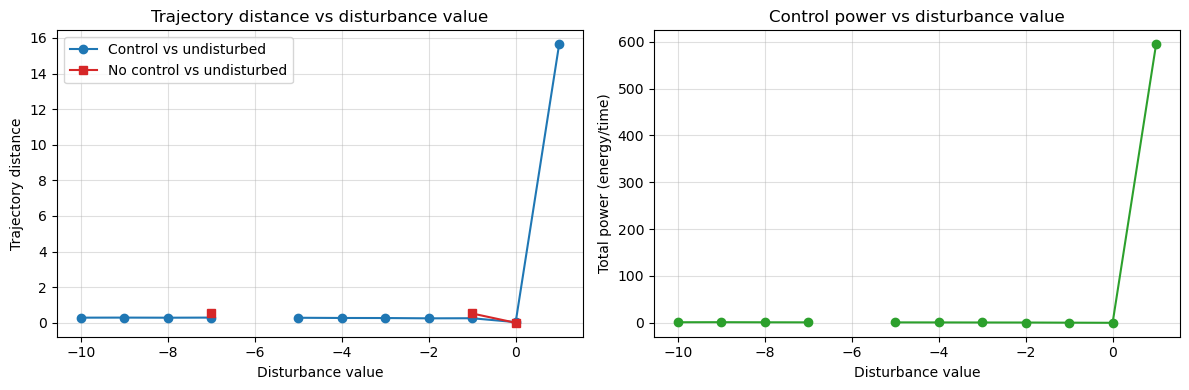

In [29]:
# Plot metrics vs disturb_value (overlay control and no-control distances)
import matplotlib.pyplot as plt
import numpy as np

vals = np.array(sweep_disturbance['disturb_values'], dtype=float)
cd = np.array(sweep_disturbance['control_distance'], dtype=float)
nc = np.array(sweep_disturbance['no_control_distance'], dtype=float)
pw = np.array(sweep_disturbance['total_power'], dtype=float)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Overlay distances on same plot
axes[0].plot(vals, cd, marker='o', label='Control vs undisturbed')
axes[0].plot(vals, nc, marker='s', color='tab:red', label='No control vs undisturbed')
axes[0].set_xlabel('Disturbance value')
axes[0].set_ylabel('Trajectory distance')
axes[0].set_title('Trajectory distance vs disturbance value')
axes[0].grid(True, alpha=0.4)
axes[0].legend()

# Power subplot
axes[1].plot(vals, pw, marker='o', color='tab:green')
axes[1].set_xlabel('Disturbance value')
axes[1].set_ylabel('Total power (energy/time)')
axes[1].set_title('Control power vs disturbance value')
axes[1].grid(True, alpha=0.4)

plt.tight_layout()
plt.show()